In [3]:
import pandas as pd
import numpy as np

#可以直接下载数据文件，但我发现也可以让爱生成哈哈，就当是对python基础内容的复习了#
# 1. 设置随机种子，保证每次生成的数据一致
np.random.seed(42)
# 2. 生成 5000 条模拟数据
num_samples = 5000
# 生成特征 (符合正态分布的随机数)
# 收入: 均值 60000, 标准差 15000
income = np.random.normal(60000, 15000, num_samples)
# 房龄: 均值 6 年, 标准差 2 年
house_age = np.random.normal(6, 2, num_samples)
# 房间数: 均值 7 间, 标准差 1.5 间
rooms = np.random.normal(7, 1.5, num_samples)
# 卧室数: 均值 4 间, 标准差 1 间
bedrooms = np.random.normal(4, 1, num_samples)
# 人口: 均值 40000, 标准差 10000
population = np.random.normal(40000, 10000, num_samples)

# 3. 生成房价 (Price)
# 假设一个线性公式（可按需设计也可上网查询）: 价格 = 截距 + 20*收入 + 150000*房龄 + 100000*房间数 + 50000*卧室数 + 10*人口 + 噪音
# 这样我们可以保证线性回归能训练出不错的结果
noise = np.random.normal(0, 50000, num_samples) # 加上一些噪音，模拟真实情况
price = -500000 + 20 * income + 150000 * house_age + 100000 * rooms + 20000 * bedrooms + 10 * population + noise

# 4. 创建 DataFrame
data = pd.DataFrame({
    'Avg. Area Income': income,
    'Avg. Area House Age': house_age,
    'Avg. Area Number of Rooms': rooms,
    'Avg. Area Number of Bedrooms': bedrooms,
    'Area Population': population,
    'Price': price
})

# 5. 保存为 CSV 文件
data.to_csv('usa_housing_price.csv', index=False)

print("成功生成 'usa_housing_price.csv' 文件！")
print(data.head())
data = pd.read_csv('usa_housing_price.csv')

# 查看数据前5行，确认数据加载成功
print(data.head())


成功生成 'usa_housing_price.csv' 文件！
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      67450.712295             5.152481                   5.982258   
1      57926.035482             5.093172                   6.541751   
2      69715.328072             2.408714                   6.103928   
3      82845.447846             5.339820                   7.165627   
4      56487.699379             7.465658                   8.795768   

   Avg. Area Number of Bedrooms  Area Population         Price  
0                      3.856577     43482.862477  2.740616e+06  
1                      3.967344     42833.235925  2.584964e+06  
2                      4.064295     30634.801542  2.232083e+06  
3                      4.946861     45795.842218  3.231214e+06  
4                      3.252783     25099.173244  2.969769e+06  
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      67450.712295             5.152481                   5.982258   
1      5

特征集形状: (5000, 5), 目标集形状: (5000,)


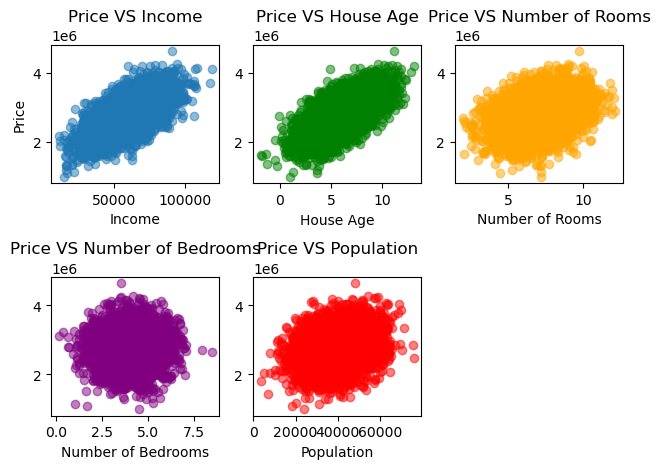

模型训练完成！
特征系数 (Coefficients): [1.99402498e+01 1.50760668e+05 9.92254780e+04 2.17497704e+04
 9.96378073e+00]
截距 (Intercept): -501439.5595088536
                                Coefficient
Avg. Area Income                  19.940250
Avg. Area House Age           150760.668137
Avg. Area Number of Rooms      99225.477964
Avg. Area Number of Bedrooms   21749.770387
Area Population                    9.963781
均方误差 (MSE): 2489125685.91418
决定系数 (R2): 0.9885061451901567


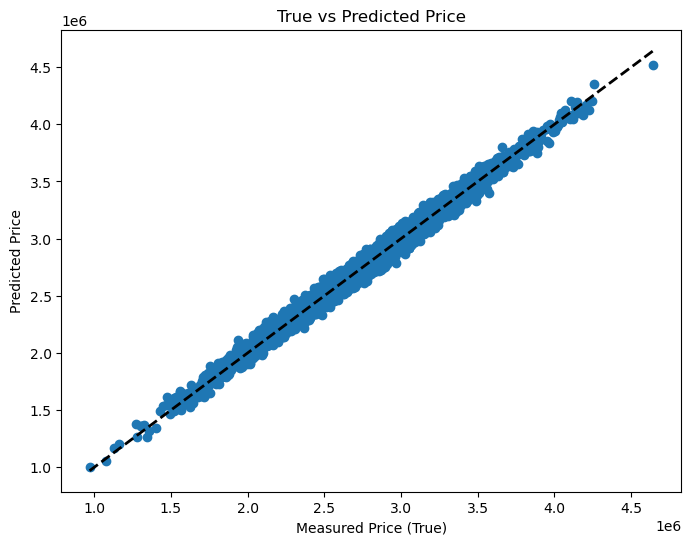

In [8]:
# 1. 导入所需的库
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import pandas as pd
import numpy as np

#2. 准备数据集
# 分离特征 X 标 y
x = data.drop('Price', axis=1) 
y = data.loc[:, 'Price']

print(f"特征集形状: {x.shape}, 目标集形状: {y.shape}")

#步骤 3：数据探索与可视化
#在训练前，我们先看看特征和房价之间的关系。讲义中使用了子图（subplot）来展示不同特征与房价的散点图 。

# 图1：收入 vs 房价
plt.subplot(2, 3, 1)
plt.scatter(x.loc[:, 'Avg. Area Income'], y, alpha=0.5)
plt.title('Price VS Income')
plt.xlabel('Income')
plt.ylabel('Price')

# 图2：房龄 vs 房价
plt.subplot(2, 3, 2)
plt.scatter(x.loc[:, 'Avg. Area House Age'], y, alpha=0.5, color='green')
plt.title('Price VS House Age')
plt.xlabel('House Age')

# 图3：房间数 vs 房价
plt.subplot(2, 3, 3)
plt.scatter(x.loc[:, 'Avg. Area Number of Rooms'], y, alpha=0.5, color='orange')
plt.title('Price VS Number of Rooms')
plt.xlabel('Number of Rooms')

# 图4：卧室数 vs 房价
plt.subplot(2, 3, 4)
plt.scatter(x.loc[:, 'Avg. Area Number of Bedrooms'], y, alpha=0.5, color='purple')
plt.title('Price VS Number of Bedrooms')
plt.xlabel('Number of Bedrooms')

# 图5：人口 vs 房价
plt.subplot(2, 3, 5)
plt.scatter(x.loc[:, 'Area Population'], y, alpha=0.5, color='red')
plt.title('Price VS Population')
plt.xlabel('Population')

plt.tight_layout()
plt.show()

#步骤 4：构建与训练模型
#这是核心步骤。我将使用 LinearRegression 拟合数据。
lr = LinearRegression()

# 模型训练（拟合）
# 注意：这里我使用了全部数据进行训练。
# 在实际工程中，通常会使用 train_test_split 切分数据，但我先按ppt走。
lr.fit(x, y)

print("模型训练完成！")

#步骤 5：查看模型参数训练好的模型本质上就是找到了一组最佳的系数（$\theta_1, \theta_2...$）和截距（$\theta_0$）。Python# 4. 查看模型参数
print('特征系数 (Coefficients):', lr.coef_)
print('截距 (Intercept):', lr.intercept_)

# 对应一下特征名称，看看哪个系数最大
coeff_df = pd.DataFrame(lr.coef_, x.columns, columns=['Coefficient'])
print(coeff_df)

#步骤 6：模型评估我们需要看看模型预测得准不准。
# 使用模型对原数据进行预测

y_predict = lr.predict(x)

# 计算 MSE (越小越好)
MSE = mean_squared_error(y, y_predict)
# 计算 R2 (越接近1越好)
R2 = r2_score(y, y_predict)

print(f"均方误差 (MSE): {MSE}")
print(f"决定系数 (R2): {R2}")

#步骤 7：结果可视化最后，我们对比一下真实房价和预测房价的分布。
plt.figure(figsize=(8, 6))
plt.scatter(y, y_predict)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # 画一条对角虚线
plt.xlabel('Measured Price (True)')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted Price')
plt.show()